# Network analysis

In [1]:
from pathlib import Path
import sys
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("./data")

SECTOR = "Industrials"
USE_ABS = True
T_MIN_SHOW, T_MAX_SHOW = 1, 30   # timestep range used for the standardized Hessian series

ADJ_PATH = DATA_DIR / "sector_Industrials_adjacency_by_relationship_connected.pickle"
META_PATH = DATA_DIR / "DF_Stock_top5_linked.csv"

# relationship types
REL_NAMES = ["competitor", "customer", "investment", "partnership", "supplier"]

## 1. Load data

In [2]:
def load_pickle_compat(path):
    """Work around unpickle failures caused by numpy version differences (numpy._core)."""
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except ModuleNotFoundError as e:
        if "numpy._core" in str(e):
            import numpy.core
            sys.modules.setdefault("numpy._core", numpy.core)
            with open(path, "rb") as f:
                return pickle.load(f)
        raise

In [3]:
# ---- relationship adjacency + company list ----
adj_payload = load_pickle_compat(ADJ_PATH)
companies = adj_payload["companies"]
rel_dict = dict(adj_payload["adjacency_by_relationship"])

# ---- build same_specific_sector dynamically from the metadata ----
meta_df = pd.read_csv(META_PATH)
meta_df.columns = [c.strip() for c in meta_df.columns]
meta_use = meta_df[["Company", "Sector"]].copy()
meta_use["Company"] = meta_use["Company"].astype(str).str.strip()
meta_use["Sector"] = meta_use["Sector"].astype(str).str.strip()
meta_use = meta_use[~meta_use["Sector"].str.lower().isin({"", "nan", "none"})].copy()
company_to_sectors = (
    meta_use.groupby("Company")["Sector"].agg(lambda s: set(s.tolist())).to_dict()
)

n = len(companies)
same_specific_sector_adj = np.zeros((n, n), dtype=np.int8)
for i in range(n):
    si = company_to_sectors.get(str(companies[i]).strip(), set())
    if not si:
        continue
    for j in range(i + 1, n):
        sj = company_to_sectors.get(str(companies[j]).strip(), set())
        if sj and (si & sj):
            same_specific_sector_adj[i, j] = 1
            same_specific_sector_adj[j, i] = 1
np.fill_diagonal(same_specific_sector_adj, 0)
rel_dict["same_specific_sector"] = same_specific_sector_adj

# upper-triangular indices (all pairs)
triu_i, triu_j = np.triu_indices(n, k=1)

print(f"sector={SECTOR}, companies={n}, pairs={len(triu_i)}")
print(f"relationships available: {list(rel_dict.keys())}")

sector=Industrials, companies=28, pairs=378
relationships available: ['competitor', 'customer', 'investment', 'partnership', 'supplier', 'same_specific_sector']


In [4]:
# ---- load the standardized Hessian, trained with the paper's exact
#      hyperparameters (epoch=2000, lr=5e-4, batch_size=128, x0=250, t=1..50) ----
def load_pkl_h(path):
    d = load_pickle_compat(path)
    return d["H_dict_avg"] if isinstance(d, dict) else d[0]


PAPER_STD = DATA_DIR / ("hessian_network_Industrials_ddpm_network_epoch2000"
                        "_paperstd_x0_250_bx0_128_S_5000_t1-50.pickle")

H_std_dict = load_pkl_h(PAPER_STD)
t_sorted = sorted(H_std_dict.keys(), key=lambda x: float(x))
t_grid = np.array([float(t) for t in t_sorted])

H_std = np.stack([np.asarray(H_std_dict[t], dtype=float) for t in t_sorted])

print(f"Hessian timesteps: {t_sorted[0]} .. {t_sorted[-1]}  (count={len(t_sorted)})")
print(f"matrix shape at t={t_sorted[0]}: {H_std[0].shape}")
print("hyperparameters: epoch=2000, lr=5e-4, batch_size=128, x0=250, S=5000, t=1..50")

Hessian timesteps: 1 .. 50  (count=50)
matrix shape at t=1: (28, 28)
hyperparameters: epoch=2000, lr=5e-4, batch_size=128, x0=250, S=5000, t=1..50


## 2. $\widetilde H_{ij}(t)$

In [5]:
def compute_Z(H_variant):
    """Per-timestep z-score across pairs, matching the original notebook's Z construction."""
    n_pairs = len(triu_i)
    Z_all = np.zeros((len(t_grid), n_pairs), dtype=float)
    for k in range(len(t_grid)):
        Mt = H_variant[k]
        v = Mt[triu_i, triu_j]
        if USE_ABS:
            v = np.abs(v)
        mu, sd = v.mean(), v.std()
        Z_all[k] = (v - mu) / sd if (sd != 0 and np.isfinite(sd)) else 0.0
    mask_show = (t_grid >= T_MIN_SHOW) & (t_grid <= T_MAX_SHOW)
    return t_grid[mask_show], Z_all[mask_show]


t_array, Z_std = compute_Z(H_std)
n_pairs = len(triu_i)
print(f"Z shape (T_used, n_pairs) = {Z_std.shape}")

Z shape (T_used, n_pairs) = (30, 378)


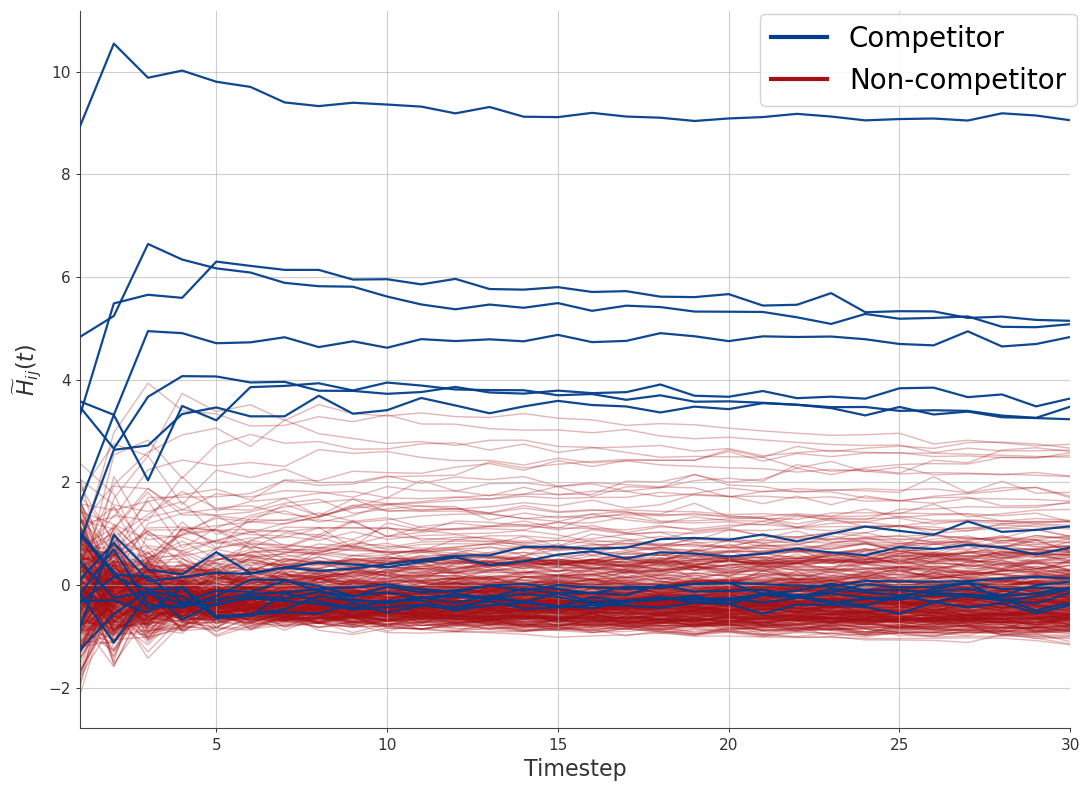

In [6]:
# ---- competitor pair mask (shared across both variants) ----
competitor_adj = np.asarray(rel_dict.get("competitor", np.zeros((n, n))))
is_comp_pair = np.array(
    [(competitor_adj[int(triu_i[k]), int(triu_j[k])] != 0
      or competitor_adj[int(triu_j[k]), int(triu_i[k])] != 0)
     for k in range(n_pairs)],
    dtype=bool,
)

BUCKETS = {
    "noncomp": {"color": "#a50f15", "lw": 1.0, "alpha": 0.30, "z": 0, "label": "Non-competitor"},
    "comp":    {"color": "#023e8a", "lw": 1.6, "alpha": 0.95, "z": 3, "label": "Competitor"},
}


def plot_z_panel(ax, Z):
    for b in ["noncomp", "comp"]:   # back -> front
        spec = BUCKETS[b]
        idxs = np.where(is_comp_pair if b == "comp" else ~is_comp_pair)[0]
        for idx in idxs:
            ax.plot(t_array, Z[:, idx], color=spec["color"], linewidth=spec["lw"],
                    alpha=spec["alpha"], zorder=spec["z"], solid_capstyle="round")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#444"); ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(axis="both", length=3, width=0.7, colors="#333", labelsize=11)
    ax.set_axisbelow(True)
    ax.set_xlabel("Timestep", fontsize=16, color="#333")
    ax.set_ylabel(r"$\widetilde H_{ij}(t)$", fontsize=16, color="#333")
    y_lo, y_hi = float(Z.min()), float(Z.max())
    pad = 0.05 * (y_hi - y_lo)
    ax.set_ylim(y_lo - pad, y_hi + pad)
    ax.set_xlim(T_MIN_SHOW, T_MAX_SHOW)
    ax.grid(True, alpha=0.6)


fig, ax = plt.subplots(1, 1, figsize=(11, 8))
plot_z_panel(ax, Z_std)


legend_handles = [
    Line2D([0], [0], color=BUCKETS["comp"]["color"], lw=3, label=BUCKETS["comp"]["label"]),
    Line2D([0], [0], color=BUCKETS["noncomp"]["color"], lw=3, label=BUCKETS["noncomp"]["label"]),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=20,
          frameon=True, framealpha=0.85, edgecolor="#cccccc")
plt.tight_layout()
plt.show()


## 3. KMeans clustering and resulting metrics

In [7]:
FIX_K, N_INIT, BASE_SEED = 2, 10, 0


def cluster_variant(Z):
    """Same clustering procedure as the original notebook, run on one variant's Z."""
    X_pairs = StandardScaler().fit_transform(Z.T.copy())
    best_score, labels = -1.0, None
    for r in range(N_INIT):
        km = KMeans(n_clusters=FIX_K, init="k-means++", n_init=1, random_state=BASE_SEED + r)
        lbl = km.fit_predict(X_pairs)
        sc = silhouette_score(X_pairs, lbl)
        if sc > best_score:
            best_score, labels = sc, lbl
    cluster_means = np.array([X_pairs[labels == k].mean() for k in range(FIX_K)])
    edge_cluster = int(np.argmax(cluster_means))

    N_ = int(max(triu_i.max(), triu_j.max())) + 1
    adj = np.zeros((N_, N_), dtype=np.int8)
    for row, (i, j) in enumerate(zip(triu_i, triu_j)):
        if labels[row] == edge_cluster:
            adj[i, j] = adj[j, i] = 1

    n_edges = int(np.triu(adj, k=1).sum())
    density = 2.0 * n_edges / (N_ * (N_ - 1))
    return {"labels": labels, "edge_cluster": edge_cluster, "silhouette": best_score,
            "adj": adj, "N": N_, "n_edges": n_edges, "density": density}


result_std = cluster_variant(Z_std)

print(f"[std] silhouette={result_std['silhouette']:.3f}, edge_cluster={result_std['edge_cluster']}, "
      f"nodes={result_std['N']}, estimated edges={result_std['n_edges']}, "
      f"density={result_std['density']:.3f}")

N = result_std["N"]
hess_companies = list(companies)[:N]
rel_dict_h = rel_dict

[std] silhouette=0.782, edge_cluster=1, nodes=28, estimated edges=21, density=0.056


/home/js/.conda/envs/fid/lib/python3.8/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [8]:
# Estimated graph vs each ground-truth relationship, as fractions.
#   TPR = overlap / gt_edges                     (true positive rate / recall)
#   FDR = (predicted - overlap) / predicted      (false discovery rate)
#   JD  = (union - overlap) / union              (Jaccard distance = 1 - Jaccard)

def relationship_metric_table(adj_est, keep_mask):
    idx = np.where(keep_mask)[0]
    sub = np.ix_(idx, idx)
    ut = np.triu(np.ones((len(idx), len(idx)), dtype=bool), k=1)
    pred = adj_est.astype(bool)[sub] & ut
    n_pred = int(pred.sum())
    rows = []
    for r in REL_NAMES:
        if r not in rel_dict_h:
            continue
        A = np.asarray(rel_dict_h[r])[:N, :N] != 0
        A = (np.logical_or(A, A.T))[sub] & ut
        inter = int(np.logical_and(pred, A).sum())
        n_gt = int(A.sum())
        union = int(np.logical_or(pred, A).sum())
        rows.append({"relationship": r, "TPR": f"{inter}/{n_gt}",
                    "FDR": f"{n_pred - inter}/{n_pred}", "JD": f"{union - inter}/{union}"})
    return pd.DataFrame(rows), n_pred


keep_all = np.ones(N, dtype=bool)
keep_no_boeing = np.array([str(c).strip() != "Boeing" for c in companies[:N]], dtype=bool)
fmt = {}

tbl_all, n_pred_all = relationship_metric_table(result_std["adj"], keep_all)
tbl_nb, n_pred_nb = relationship_metric_table(result_std["adj"], keep_no_boeing)
print(f"[All nodes]  N={N}, predicted edges={n_pred_all}")
print(tbl_all.to_string(index=False))
print(f"\n[Boeing excluded]  N={int(keep_no_boeing.sum())}, predicted edges={n_pred_nb}")
print(tbl_nb.to_string(index=False))

[All nodes]  N=28, predicted edges=21
relationship  TPR   FDR    JD
  competitor 7/17 14/21 24/31
    customer 6/25 15/21 34/40
  investment 0/12 21/21 33/33
 partnership 4/21 17/21 34/38
    supplier 6/25 15/21 34/40

[Boeing excluded]  N=27, predicted edges=20
relationship  TPR   FDR    JD
  competitor 7/12 13/20 18/25
    customer 5/18 15/20 28/33
  investment  0/8 20/20 28/28
 partnership 3/14 17/20 28/31
    supplier 5/18 15/20 28/33


## 4. Estimated graph — shared layout

In [9]:
# ---- shared layout: frozen node coordinates ----
# Node positions are pinned to `network_results.ipynb`. They were produced once by
# seeding spring_layout with the union of the ORIGINAL paper checkpoint's estimated
# graph and all ground-truth relationships, then frozen to `data/network_layout.json`
# so this notebook needs no raw-input artefact to place its nodes.
#
# The layout includes random jitter (`rng.normal`), so it is reproducible only by
# replaying the exact original call sequence -- which is precisely why the
# coordinates are stored rather than recomputed. Do not regenerate them: doing so
# would move every node and break alignment with `network_results.ipynb`.
LAYOUT_PATH = DATA_DIR / "network_layout.json"

with open(LAYOUT_PATH) as f:
    _layout = json.load(f)

pos = {k: np.asarray(v, dtype=float) for k, v in _layout["pos"].items()}

missing = [nm for nm in hess_companies if nm not in pos]
if missing:
    raise KeyError(f"network_layout.json is missing {len(missing)} node(s): {missing[:5]}")

print(f"loaded frozen layout: {len(pos)} nodes from {LAYOUT_PATH.name}")


loaded frozen layout: 28 nodes from network_layout.json


In [10]:
# Common axis range, derived from the frozen coordinates.
all_xy = np.array([pos[nm] for nm in hess_companies], dtype=float)
xmin, ymin = all_xy.min(axis=0) - 0.4
xmax, ymax = all_xy.max(axis=0) + 0.4
print(f"layout bbox: x[{xmin:.2f},{xmax:.2f}] y[{ymin:.2f},{ymax:.2f}]")


layout bbox: x[-2.85,2.66] y[-2.65,2.68]


In [11]:
# ---- label placement rules (shared) ----
center_xy = all_xy.mean(axis=0)

def angle_offset(name):
    x, y = pos[name]
    deg_ = float(np.degrees(np.arctan2(y - center_xy[1], x - center_xy[0])))
    if -45 <= deg_ <= 45:
        return (0.18, 0.0, "left", "center")
    elif 45 < deg_ <= 135:
        return (0.0, 0.18, "center", "bottom")
    elif -135 <= deg_ < -45:
        return (0.0, -0.22, "center", "top")
    else:
        return (-0.18, 0.0, "right", "center")

manual_offsets = {
    "UPS":                           (0.00, 0.01, "left", "bottom"),
    "Huntington Ingalls Industries": (0.01, 0.01, "left", "bottom"),
    "Southwest Airlines":            (-0.01, -0.01, "right", "top"),
    "Delta Air Lines":               (0.00, 0.01, "center", "top"),
    "General Dynamics":              (0.01, 0.01, "left", "bottom"),
    "Paccar":                        (0.01, 0.00, "left", "bottom"),
    "Cummins":                       (0.01, 0.00, "left", "bottom"),
    "Waste Management":              (-0.01, -0.01, "right", "top"),
    "Republic Services":             (-0.01, -0.01, "right", "top"),
    "Boeing":                        (0.01, 0.01, "left", "center"),
    "Lockheed Martin":               (0.01, 0.01, "left", "bottom"),
    "Quanta Services":               (0.01, 0.01, "left", "bottom"),
    "Honeywell":                     (0.01, 0.01, "left", "bottom"),
    "TransDigm Group":               (0.01, 0.01, "left", "bottom"),
    "Equifax":                       (-0.01, -0.01, "right", "top"),
    "FedEx":                         (0.01, 0.01, "left", "bottom"),
    "Paychex":                       (-0.01, -0.01, "right", "top"),
    "ADP":                           (-0.01, -0.01, "right", "top"),
    "Wabtec":                        (-0.01, -0.01, "right", "top"),
    "United Rentals":                (0.01, 0.01, "left", "bottom"),
    "Ingersoll-Rand":                (-0.01, -0.01, "right", "top"),
}

In [12]:
LABEL_PAD = 0.6
LABEL_FS_CONNECTED = 14
LABEL_FS_ISOLATED = 10


def draw_panel(ax, adj_mat, title, edge_color, node_color="#d62728"):
    """Draw a binary adjacency on the shared layout `pos` with the shared label rules."""
    ax.set_facecolor("#fbfbfb")
    G = nx.Graph()
    G.add_nodes_from(hess_companies)
    edge_list = []
    for i in range(N):
        for j in range(i + 1, N):
            if adj_mat[i, j]:
                G.add_edge(hess_companies[i], hess_companies[j])
                edge_list.append((hess_companies[i], hess_companies[j]))

    deg = dict(G.degree())
    connected_nodes = [nn for nn, d in deg.items() if d > 0]
    isolated_nodes = [nn for nn, d in deg.items() if d == 0]

    if edge_list:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge_list,
                               edge_color="black", width=1.6, alpha=0.85)
    if connected_nodes:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=connected_nodes,
                               node_size=55, node_color=node_color, alpha=0.9, linewidths=0)
    if isolated_nodes:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=isolated_nodes,
                               node_size=28, node_color="#c5c5c5", alpha=0.8, linewidths=0)

    for nn in hess_companies:
        color = "#111111" if deg[nn] > 0 else "#888888"
        fs = LABEL_FS_CONNECTED if deg[nn] > 0 else LABEL_FS_ISOLATED
        dx, dy, ha, va = manual_offsets.get(nn, angle_offset(nn))
        ax.text(pos[nn][0] + dx, pos[nn][1] + dy, str(nn),
                fontsize=fs, color=color, alpha=0.95, ha=ha, va=va, zorder=10)

    n_e = len(edge_list)
    legend_handle = Line2D([0], [0], color=edge_color, lw=2.5,
                           label=f"{title} (number of edges={n_e})")
    ax.legend(handles=[legend_handle], loc="upper center", bbox_to_anchor=(0.5, 1.03),
              frameon=False, fontsize=15)
    ax.set_xlim(xmin - LABEL_PAD, xmax + LABEL_PAD)
    ax.set_ylim(ymin - LABEL_PAD, ymax + LABEL_PAD)
    ax.set_aspect("equal")
    ax.axis("off")
    return n_e

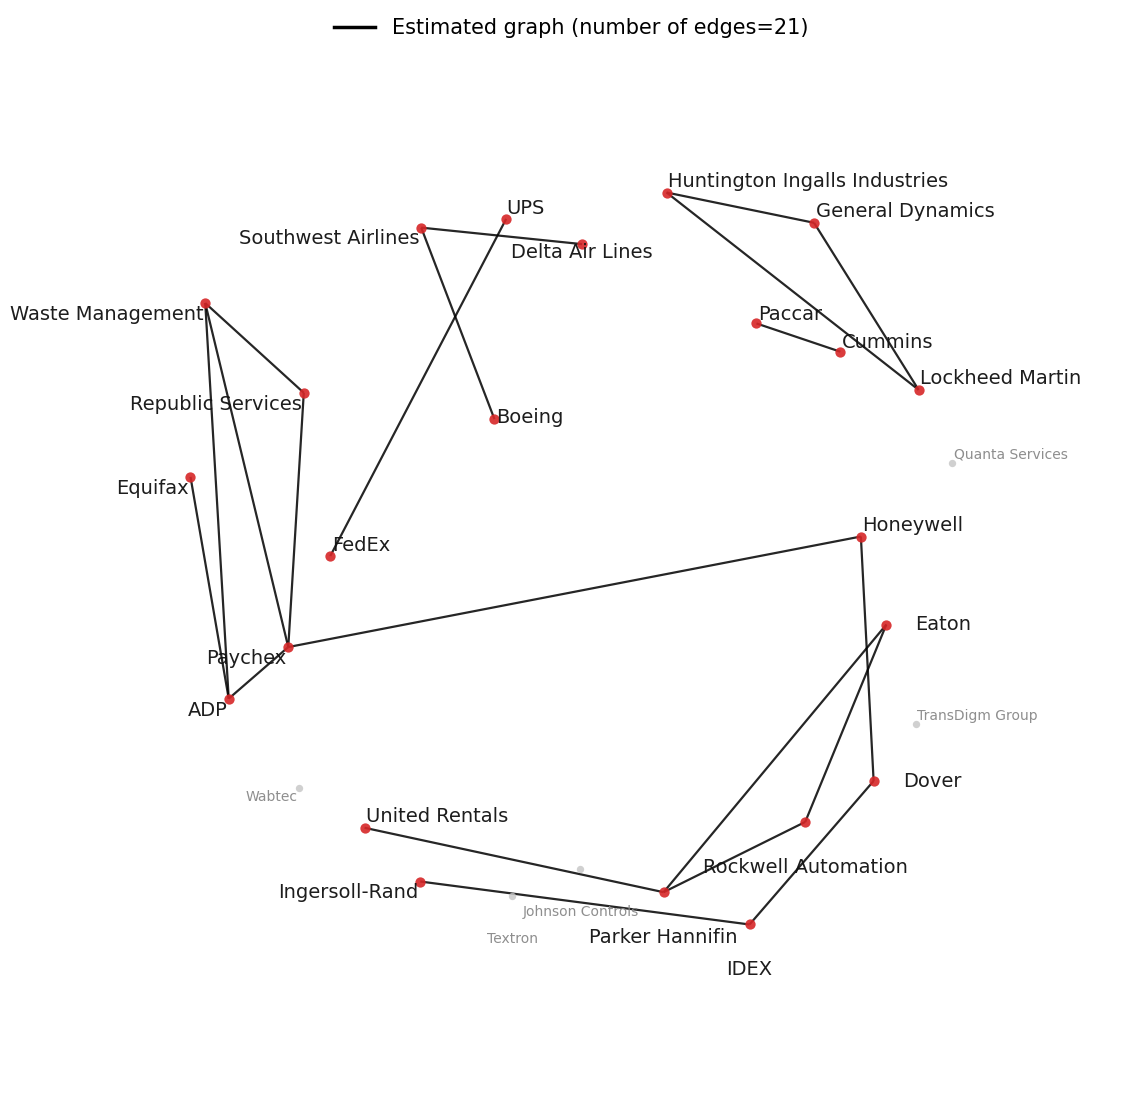

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(13, 11), facecolor="white")
draw_panel(ax, result_std["adj"], "Estimated graph", "black")
plt.tight_layout()
plt.show()


## 5. Reference relationship network graph

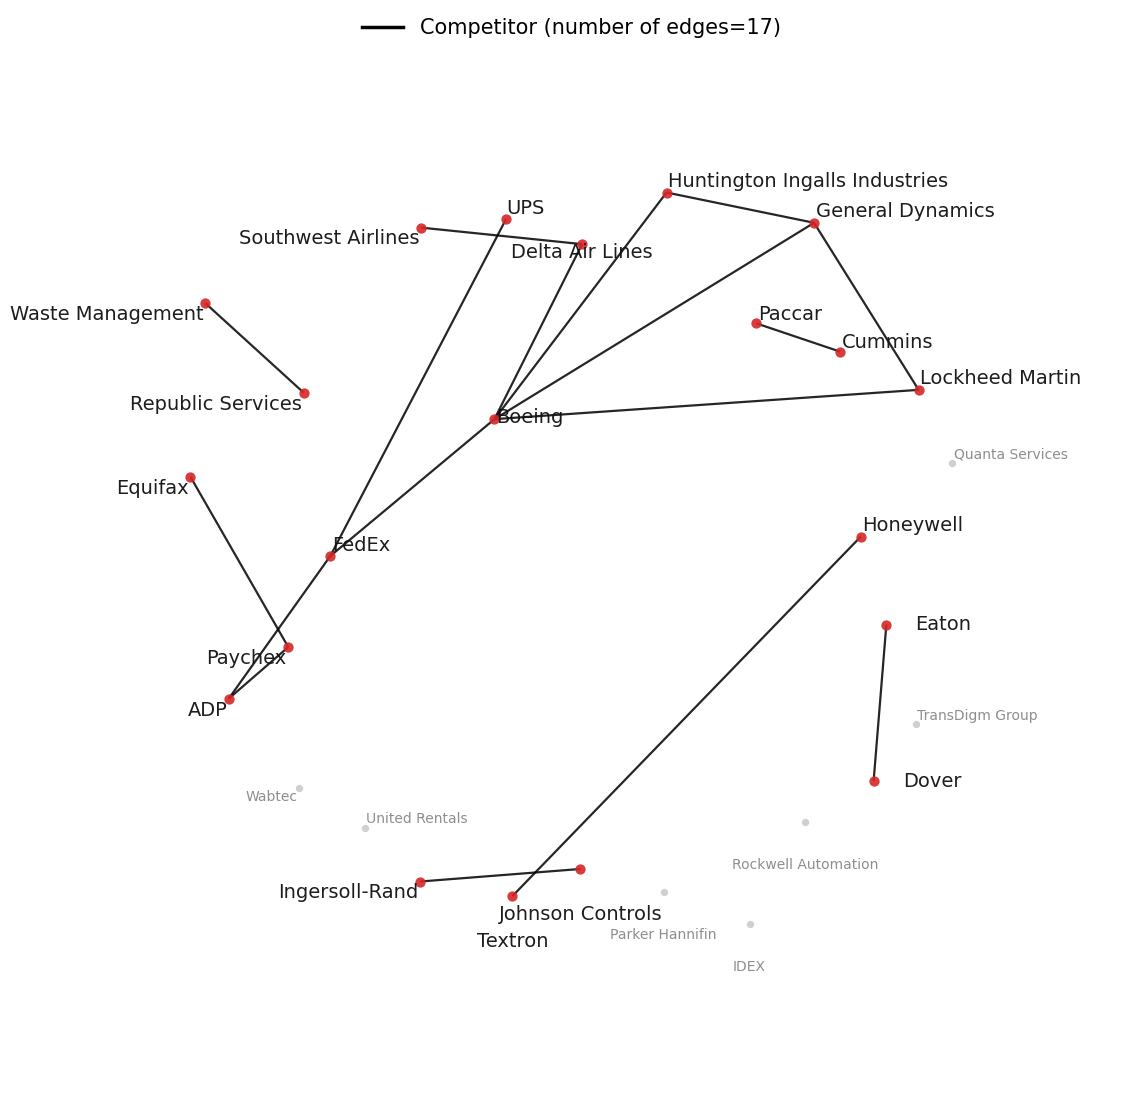

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(13, 11), facecolor="white")

key = "competitor"
A = np.asarray(rel_dict_h[key])[:N, :N] != 0
A = np.logical_or(A, A.T).astype(np.int8)
np.fill_diagonal(A, 0)
draw_panel(ax, A, "Competitor", "black")

plt.tight_layout()
plt.show()

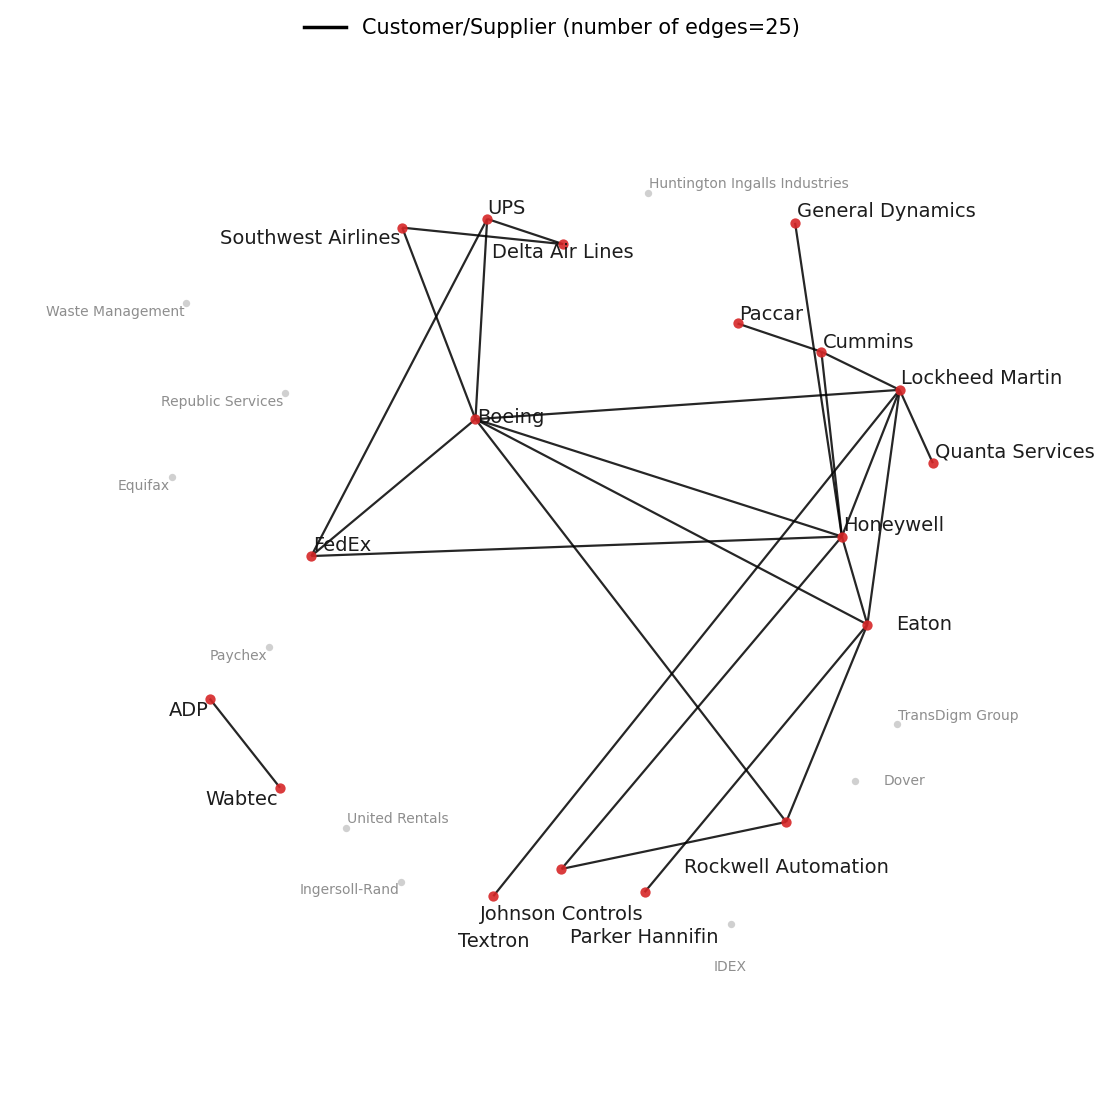

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(13, 11), facecolor="white")

key = "customer"
A = np.asarray(rel_dict_h[key])[:N, :N] != 0
A = np.logical_or(A, A.T).astype(np.int8)
np.fill_diagonal(A, 0)
draw_panel(ax, A, "Customer/Supplier", "black")

plt.tight_layout()
plt.show()

## 6. $\widetilde H_{ij}(t)$ for all pairs $(i,j)$, colored by competitor label and inclusion in $\widehat G$

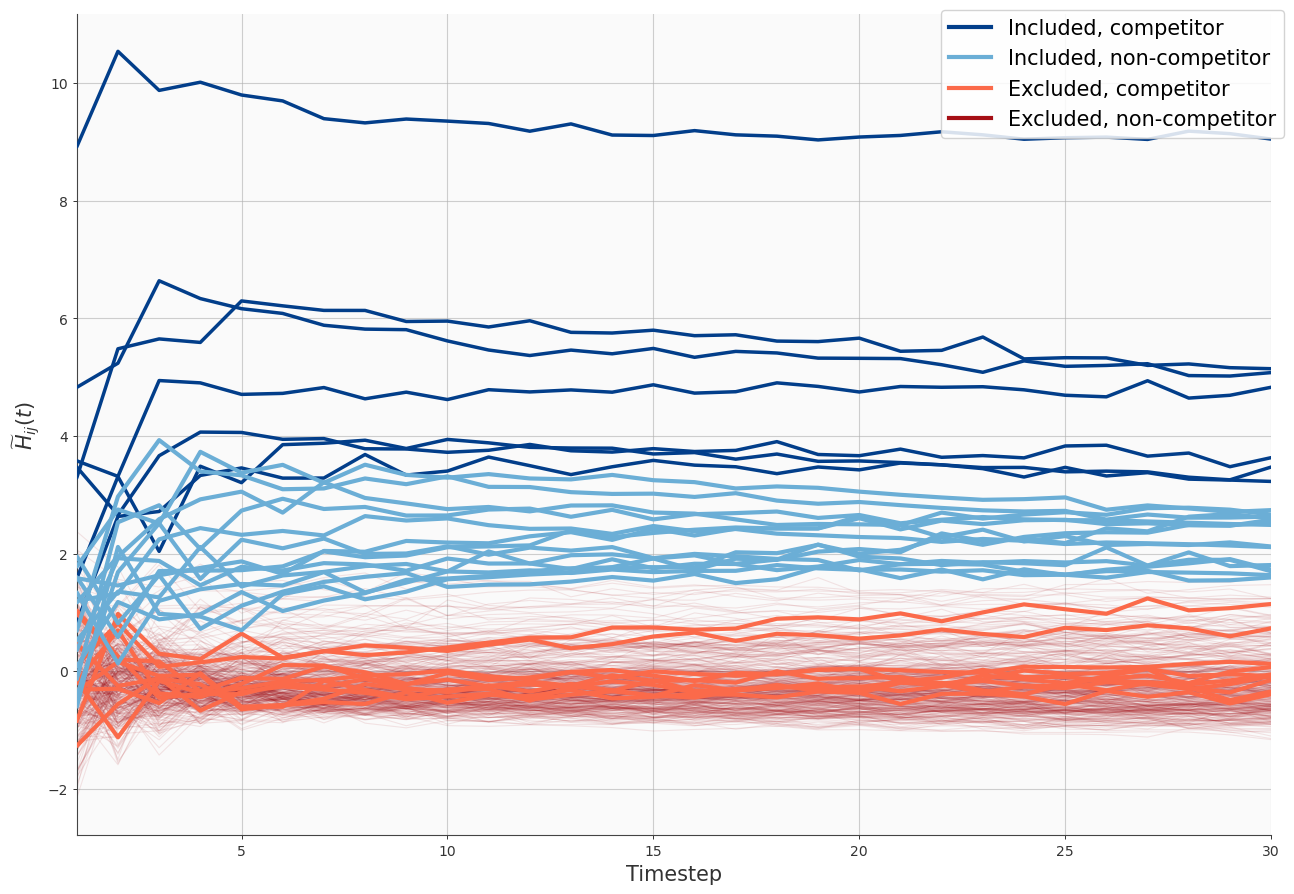

In [16]:
BUCKETS7 = {
    "inc_comp":    {"color": "#023e8a", "lw": 2.5, "alpha": 1.0, "z": 4,  "label": "Included, competitor"},
    "inc_noncomp": {"color": "#6baed6", "lw": 3.0, "alpha": 1.0, "z": 10, "label": "Included, non-competitor"},
    "exc_comp":    {"color": "#fb6a4a", "lw": 3.0, "alpha": 1.0, "z": 10, "label": "Excluded, competitor"},
    "exc_noncomp": {"color": "#a50f15", "lw": 0.8, "alpha": 0.1, "z": 1,  "label": "Excluded, non-competitor"},
}
draw_order = ["exc_noncomp", "exc_comp", "inc_noncomp", "inc_comp"]


def plot_panel7(ax, Z, is_included):
    bucket_idx = {
        "exc_noncomp": np.where(~is_included & ~is_comp_pair)[0],
        "exc_comp":    np.where(~is_included &  is_comp_pair)[0],
        "inc_noncomp": np.where( is_included & ~is_comp_pair)[0],
        "inc_comp":    np.where( is_included &  is_comp_pair)[0],
    }
    ax.set_facecolor("#fafafa")
    for b in draw_order:
        spec = BUCKETS7[b]
        for idx in bucket_idx[b]:
            ax.plot(t_array, Z[:, idx], color=spec["color"], linewidth=spec["lw"],
                    alpha=spec["alpha"], zorder=spec["z"], solid_capstyle="round")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#444"); ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(axis="both", length=3, width=0.7, colors="#333", labelsize=10)
    ax.set_axisbelow(True)
    ax.set_xlabel("Timestep", fontsize=15, color="#333")
    ax.set_ylabel(r"$\widetilde H_{ij}(t)$", fontsize=15, color="#333")
    y_lo, y_hi = float(Z.min()), float(Z.max())
    pad = 0.05 * (y_hi - y_lo)
    ax.set_ylim(y_lo - pad, y_hi + pad)
    ax.set_xlim(T_MIN_SHOW, T_MAX_SHOW)
    ax.grid(True, alpha=0.6)


fig, ax = plt.subplots(1, 1, figsize=(13, 9))
plot_panel7(ax, Z_std, result_std["labels"] == result_std["edge_cluster"])

legend_order = ["inc_comp", "inc_noncomp", "exc_comp", "exc_noncomp"]
legend_handles = [Line2D([0], [0], color=BUCKETS7[b]["color"], lw=3, label=BUCKETS7[b]["label"])
                  for b in legend_order]
fig.legend(handles=legend_handles, loc="upper right",  fontsize=15,
          frameon=True, framealpha=0.85, edgecolor="#cccccc")
plt.tight_layout()
plt.show()


## 7. Company pairs for which the estimated graph and the competitor relationship disagree

In [17]:
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 160)
fmt = {"meanZ": "{:7.3f}".format}

mean_z = Z_std.mean(axis=0)
order_z = np.argsort(-mean_z)
rows = []
for rk, k in enumerate(order_z, start=1):
    i, j = int(triu_i[k]), int(triu_j[k])
    rows.append({"rank": rk, "company1": companies[i], "company2": companies[j],
                "meanZ": mean_z[k], "competitor": "YES" if is_comp_pair[k] else ""})
ranking = pd.DataFrame(rows)
print(f"mean_z ranking (top 15 of {n_pairs} pairs)")
print(ranking.head(15).to_string(index=False, formatters=fmt))

mean_z ranking (top 15 of 378 pairs)
 rank                      company1                      company2   meanZ competitor
    1             Republic Services              Waste Management   9.299        YES
    2                         FedEx                           UPS   5.581        YES
    3              General Dynamics               Lockheed Martin   5.469        YES
    4                           ADP                       Paychex   4.689        YES
    5               Delta Air Lines            Southwest Airlines   3.719        YES
    6                       Cummins                        Paccar   3.461        YES
    7              General Dynamics Huntington Ingalls Industries   3.297        YES
    8               Parker Hannifin           Rockwell Automation   3.054           
    9               Parker Hannifin                United Rentals   2.904           
   10                         Eaton               Parker Hannifin   2.536           
   11                       

In [18]:
def disagreement_table(mean_z, mask):
    rows = []
    for k in np.where(mask)[0]:
        i, j = int(triu_i[k]), int(triu_j[k])
        rows.append({"company1": companies[i], "company2": companies[j], "meanZ": mean_z[k]})
    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values("meanZ", ascending=False).reset_index(drop=True)
        df.insert(0, "rank", df.index + 1)
    return df


mean_z = Z_std.mean(axis=0)
is_included = result_std["labels"] == result_std["edge_cluster"]

included_noncompetitor = disagreement_table(mean_z, is_included & ~is_comp_pair)
competitor_excluded = disagreement_table(mean_z, ~is_included & is_comp_pair)

print(f"Included but non-competitor  ({len(included_noncompetitor)} pairs)")
print(included_noncompetitor.to_string(index=False, formatters=fmt))
print(f"\nCompetitor but excluded  ({len(competitor_excluded)} pairs)")
print(competitor_excluded.to_string(index=False, formatters=fmt))

Included but non-competitor  (14 pairs)
 rank                      company1            company2   meanZ
    1               Parker Hannifin Rockwell Automation   3.054
    2               Parker Hannifin      United Rentals   2.904
    3                         Eaton     Parker Hannifin   2.536
    4                         Eaton Rockwell Automation   2.505
    5                           ADP             Equifax   2.296
    6                         Dover                IDEX   2.257
    7 Huntington Ingalls Industries     Lockheed Martin   2.196
    8                         Dover           Honeywell   1.818
    9                        Boeing  Southwest Airlines   1.785
   10                       Paychex   Republic Services   1.766
   11                       Paychex    Waste Management   1.765
   12                          IDEX      Ingersoll-Rand   1.762
   13                     Honeywell             Paychex   1.568
   14                           ADP    Waste Management   1.561
